# U.S. Election Voter Analysis using ANES 2024

This notebook contains the corrected loading and cleaning steps.

## 1. Abstract

This project analyzes respondent-level data from the ANES 2024 Time Series Study. The goal is to study how voting behavior in the 2024 U.S. presidential election is related to demographic variables such as age, race/ethnicity, gender, education, income, state, and political ideology.

## 2. Dataset description

The dataset used in this project is the ANES 2024 Time Series Study. It contains survey responses from people eligible to vote in the United States. The selected columns include respondent ID, state of registration, presidential vote, turnout, age, education, race/ethnicity, sex/gender, income, and ideology.

Important correction: `V241017` is not suitable as the main state variable because it is only a confirmation-state question and is mostly inapplicable. I use `V242058x`, the pre-post summary state of registration, instead. Also, `V241039` is a pre-election early-vote question, so it is mostly inapplicable. I use `V242096x`, the pre-post summary presidential vote, as the main presidential vote variable.

## 3. Loading the dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)

In [2]:
df = pd.read_csv("../data/raw/anes_timeseries_2024_csv_20260519.csv", low_memory=False)

display(df.head())
print("Shape:", df.shape)

,version,V240001,V200001,V160001_orig,V240002a,V240002b,V240002c,V240003,V240101a,V240101b,V240101c,V240101d,V240102a,V240102b,V240102c,V240102d,V240103a,V240103b,V240103c,V240103d,V240104a,V240104b,V240104c,V240104d,V240105a,V240105b,V240105c,V240105d,V240106a,V240106b,V240106c,V240106d,V240107a,V240107b,V240107c,V240107d,V240108a,V240108b,V240108c,V240108d,V241001,V241002,V241003,V241004,V241005,V241006,V241007,V241008x,V241009,V241010,...,V244259,V244260,V244261,V244262,V244263,V244264,V244265,V244266,V244267,V244268,V244269,V244270,V244271,V244272,V244273,V244274,V244275,V244276,V244277,V244278,V244279,V244280,V244281,V244282,V244283,V244284,V244285,V244286,V244287,V244288,V244289,V244290,V245001,V245002,V245003,V245004,V245005,V245006,V245007,V245008,V245009,V245010,V245011,V245012,V245013,V245014,V245015,V245016,V245017,V245018
0,ANES2024TimeSeries_20260519,140001,200015,401318,2,2,2,1,,,,,,,,,,,,,,,,,,,,,.926752673075417,.944649211118401,2,9,0.716602,.710864874498513,2,93,.809064446525151,.780974621163524,2,90,1,-1,-1,2,1,2,1,4,2,1,...,1,1,5,0,2,6,3,4,1,0,2,4,3,1,0,1,2,1,2,0,3,0,1,4,2,5,0,1,3,2,1,2,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
1,ANES2024TimeSeries_20260519,140002,200022,300261,2,2,2,1,,,,,,,,,,,,,,,,,,,,,2.97990209565835,3.06178194522418,2,26,2.354582,2.38378558802356,2,110,2.57547228125883,2.50707498962934,2,107,1,-1,-1,3,3,2,2,3,1,1,...,1,2,0,5,6,4,1,3,2,4,0,1,3,2,0,2,1,0,1,2,1,0,5,4,2,3,3,2,0,1,1,3,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
2,ANES2024TimeSeries_20260519,140003,200039,400181,2,2,2,1,,,,,,,,,,,,,,,,,,,,,1.13426633346479,1.14258418425449,1,41,0.780178,.808992408255851,1,125,.798863720384672,.814400897948447,1,122,1,-1,-1,2,1,1,1,1,1,1,...,1,1,5,6,2,4,0,3,1,4,2,0,3,1,2,0,1,0,1,2,3,4,0,5,1,2,0,3,1,2,2,5,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
3,ANES2024TimeSeries_20260519,140004,200046,300171,2,2,2,1,,,,,,,,,,,,,,,,,,,,,.438687743184118,.468714285660617,2,29,0.268988,.291739965421631,2,113,.244756736207129,.263490124186044,2,110,1,-1,-1,4,2,2,1,4,1,1,...,1,2,0,5,4,3,6,1,1,1,4,3,0,2,0,1,2,2,0,1,2,0,1,5,3,4,1,2,0,3,1,2,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
4,ANES2024TimeSeries_20260519,140005,200053,405145,2,2,2,1,,,,,,,,,,,,,,,,,,,,,.384116482751774,.350433898077436,1,23,0.244306,.222012175174604,1,107,.239209031155281,.216673241876399,1,104,1,-1,-1,2,2,2,2,3,1,1,...,1,1,5,0,4,3,2,6,1,1,0,3,4,2,0,2,1,1,0,2,1,0,4,2,3,5,2,0,3,1,2,1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1


Shape: (5521, 1738)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5521 entries, 0 to 5520
Columns: 1738 entries, version to V245018
dtypes: float64(3), int64(1681), object(54)
memory usage: 73.2+ MB


In [4]:
df.describe()

,V240001,V200001,V160001_orig,V240002a,V240002b,V240002c,V240003,V240107a,V240107c,V240107d,V241001,V241002,V241003,V241004,V241005,V241006,V241007,V241008x,V241009,V241010,V241012,V241013,V241014,V241015,V241016,V241017,V241018,V241019,V241020,V241021,V241022,V241023,V241024,V241025,V241025z,V241027,V241028,V241029,V241030,V241031,V241032,V241033,V241034,V241035,V241036,V241037,V241038,V241039,V241039z,V241040,...,V244257,V244258,V244259,V244260,V244261,V244262,V244263,V244264,V244265,V244266,V244267,V244268,V244269,V244270,V244271,V244272,V244273,V244274,V244275,V244276,V244277,V244278,V244279,V244280,V244281,V244282,V244283,V244284,V244285,V244286,V244287,V244288,V244289,V244290,V245002,V245003,V245004,V245005,V245006,V245007,V245008,V245009,V245011,V245012,V245013,V245014,V245015,V245016,V245017,V245018
count,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.00000,5521.000000,5521.000000,5521.000000,5521.0,5521.000000,5521.000000,5521.000000,5521.000000,5521.0,5521.000000,5521.000000,5521.0,5521.000000,5521.0,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.0,5521.000000,...,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000
mean,214468.828473,85779.698424,149691.869408,1.896939,1.426915,1.899112,1.795508,1.000000,24.911610,69.830647,0.920667,-0.616193,-0.526897,2.447745,1.515124,1.206665,1.171708,2.225503,1.390147,0.911248,0.96468,-0.784640,0.973918,-0.918312,-3.0,-0.919761,-0.850389,-0.853287,-0.850389,-3.0,0.894222,24.910342,-3.0,0.444485,-3.0,0.645897,0.094910,0.456982,-0.820322,2.137837,-0.390871,-0.497555,-0.860533,1.810904,-0.882449,-0.902554,-0.925376,-0.909618,-2.0,-0.923021,...,0.604057,0.611302,0.623981,2.207028,2.210831,2.219344,2.239812,2.270422,2.220974,2.215178,1.009962,1.411339,1.423474,1.435791,1.406810,1.420938,0.606050,0.613476,0.619815,0.612027,0.616193,0.611121,1.813621,1.778844,1.850571,1.810904,1.859627,1.824126,1.015758,1.024271,1.017569,1.007970,0.689368,1.956348,245.480891,-1.057055,-1.340156,-1.158486,-0.751494,-0.750951,-0.685745,-0.603333,250.426191,-0.858721,-1.164825,-0.977359,-0.568556,-0.796595,-0.704583,-0.698605
std,77453.441194,106769.551324,187910.024862,0.513647,2.660526,0.301207,0.735011,1.054148,65.369314,36.675315,0.447872,0.799650,1.020821,1.097525,0.888023,1.344284,0.739813,1.513242,0.710127,0.411895,0.57674,1.062617,0.606762,0.463946,0.0,1.687092,0.526201,0.518701,0.526201,0.0,0.428222,17.658519,0.0,1.795790,0.0,0.563492,0.417955,0.580485,0.691008,1.248630,1.648479,1.309125,0.754048,0.675206,0.530024,0.509613,0.381942,0.544721,0.0,0.404746,...,1.073602,1.079272,1.080910,2.391121,2.380575,2.397590,2.386271,2.394410,2.400725,2.395511,1.082005,1.731049,1.735703,1.744945,1.727563,1.746515,1.073744,1.078038,1.082050,1.074150,1.079596,1.080130,2.061606,2.039331,2.082524,2.059996,2.083676,2.061914,1.410085,1.405008,1.409678,1.408929,2.273599,3.000075,652.186498,2.407831,2.045107,2.237053,2.946720,0.554716,0.683099,0.954328,657.642506,2.075207,1.648452,1.863171,2.637257,0.483529,0.681161,0.790166
min,140001.000000,-1.000000,-1.000000,1.000000,-7.000000,1.000000,1.000000,0.045193,1.000000,1.000000,-9.000000,-1.000000,-8.000000,-9.000000,-9.000000,-9

## 3.1. Selecting useful columns

The ANES dataset has many columns. I select only the variables needed for this project.

In [4]:
selected_columns = {
    "V240001": "respondent_id",
    "V242058x": "state",                         # PRE-POST summary state of registration
    "V242096x": "presidential_vote",             # PRE-POST summary 2024 presidential vote
    "V242095x": "voter_turnout",                 # PRE-POST summary voter turnout
    "V241075x": "pre_election_presidential_choice", # pre-election vote/intent/preference summary
    "V241458x": "age",
    "V241465x": "education",
    "V241501x": "race_ethnicity",
    "V241550": "sex",
    "V241551": "gender",
    "V241566x": "income",
    "V241177": "ideology"
}

df_selected = df[list(selected_columns.keys())].rename(columns=selected_columns).copy()

display(df_selected.head())
print("Selected shape:", df_selected.shape)

,respondent_id,state,presidential_vote,voter_turnout,pre_election_presidential_choice,age,education,race_ethnicity,sex,gender,income,ideology
0,140001,40,2,1,21,50,4,3,1,1,27,6
1,140002,16,-2,0,22,41,3,4,2,2,26,4
2,140003,51,1,1,20,44,3,1,2,2,24,2
3,140004,6,-2,0,21,45,3,4,1,1,12,99
4,140005,8,2,1,21,80,5,1,1,1,15,4


Selected shape: (5521, 12)


In [5]:
for column in df_selected.columns:
    print("\n" + "=" * 80)
    print(column)
    print(df_selected[column].value_counts(dropna=False).head(20))


respondent_id
respondent_id
140001    1
225876    1
225978    1
225972    1
225954    1
225936    1
225924    1
225912    1
225900    1
225894    1
225859    1
225990    1
225847    1
225835    1
225817    1
225805    1
225800    1
225758    1
225723    1
225717    1
Name: count, dtype: int64

state
state
-1     634
 6     409
 48    356
 12    283
 36    198
 17    198
 26    189
 42    185
 39    174
 13    152
 29    144
 37    144
 47    130
 51    130
 18    127
 55    127
 53    126
 34    121
 25    115
 45    108
Name: count, dtype: int64

presidential_vote
presidential_vote
 1    2201
 2    1747
-2    1468
 6      63
 5      25
 4      13
 3       4
Name: count, dtype: int64

voter_turnout
voter_turnout
 1    4137
 0     835
-2     549
Name: count, dtype: int64

pre_election_presidential_choice
pre_election_presidential_choice
 20    2303
 21    1910
-2      396
 22     326
 31     207
 30     147
 10     114
 11      74
 32      34
 12      10
Name: count, dtype: int64

age


## 4. Data cleaning

ANES uses negative numeric codes for special missing/admin values such as refused, don't know, inapplicable, no post-interview, or insufficient partial interview. I replace negative codes with `NaN`. I also replace ideology code `99`, because it means “Haven't thought much about this” and is not part of the 1–7 ideology scale.

In [8]:
df_clean = df_selected.copy()

# Save missingness before cleaning.
missing_before = df_clean.isna().sum()

# Convert selected numeric columns and replace ANES negative special codes with NaN.
for column in df_clean.columns:
    if column != "respondent_id":
        df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")
        df_clean.loc[df_clean[column] < 0, column] = np.nan

# For ideology, 99 is not a position on the 1-7 liberal-conservative scale.
df_clean["ideology"] = df_clean["ideology"].replace(99, np.nan)

#Show how the database changed after replacing all invalid negative codes with NaN.
cleaning_report = pd.DataFrame({
    "missing_before": missing_before,
    "missing_after": df_clean.isna().sum()
})

cleaning_report["new_missing_after_cleaning"] = (
    cleaning_report["missing_after"] - cleaning_report["missing_before"]
)

cleaning_report

,missing_before,missing_after,new_missing_after_cleaning
respondent_id,0,0,0
state,0,634,634
presidential_vote,0,1468,1468
voter_turnout,0,549,549
pre_election_presidential_choice,0,396,396
age,0,279,279
education,0,56,56
race_ethnicity,0,67,67
sex,0,46,46
gender,0,287,287


In [9]:
for column in df_clean.columns:
    print("\n" + "=" * 80)
    print(column)
    print(df_clean[column].value_counts(dropna=False).head(20))


respondent_id
respondent_id
140001    1
225876    1
225978    1
225972    1
225954    1
225936    1
225924    1
225912    1
225900    1
225894    1
225859    1
225990    1
225847    1
225835    1
225817    1
225805    1
225800    1
225758    1
225723    1
225717    1
Name: count, dtype: int64

state
state
NaN     634
6.0     409
48.0    356
12.0    283
36.0    198
17.0    198
26.0    189
42.0    185
39.0    174
13.0    152
29.0    144
37.0    144
47.0    130
51.0    130
18.0    127
55.0    127
53.0    126
34.0    121
25.0    115
45.0    108
Name: count, dtype: int64

presidential_vote
presidential_vote
1.0    2201
2.0    1747
NaN    1468
6.0      63
5.0      25
4.0      13
3.0       4
Name: count, dtype: int64

voter_turnout
voter_turnout
1.0    4137
0.0     835
NaN     549
Name: count, dtype: int64

pre_election_presidential_choice
pre_election_presidential_choice
20.0    2303
21.0    1910
NaN      396
22.0     326
31.0     207
30.0     147
10.0     114
11.0      74
32.0      34
12.0

## 4.1. Adding readable labels

Most ANES variables are coded as numbers, so I create readable label columns. This makes plots and tables easier to visualize and understand.

In [10]:
state_codes = {
    1:"Alabama", 2:"Alaska", 4:"Arizona", 5:"Arkansas", 6:"California", 8:"Colorado",
    9:"Connecticut", 10:"Delaware", 11:"District of Columbia", 12:"Florida", 13:"Georgia",
    15:"Hawaii", 16:"Idaho", 17:"Illinois", 18:"Indiana", 19:"Iowa", 20:"Kansas",
    21:"Kentucky", 22:"Louisiana", 23:"Maine", 24:"Maryland", 25:"Massachusetts",
    26:"Michigan", 27:"Minnesota", 28:"Mississippi", 29:"Missouri", 30:"Montana",
    31:"Nebraska", 32:"Nevada", 33:"New Hampshire", 34:"New Jersey", 35:"New Mexico",
    36:"New York", 37:"North Carolina", 38:"North Dakota", 39:"Ohio", 40:"Oklahoma",
    41:"Oregon", 42:"Pennsylvania", 44:"Rhode Island", 45:"South Carolina",
    46:"South Dakota", 47:"Tennessee", 48:"Texas", 49:"Utah", 50:"Vermont",
    51:"Virginia", 53:"Washington", 54:"West Virginia", 55:"Wisconsin", 56:"Wyoming"
}

vote_labels = {
    1:"Kamala Harris",
    2:"Donald Trump",
    3:"Robert F. Kennedy Jr.",
    4:"Cornel West",
    5:"Jill Stein",
    6:"Other"
}

turnout_labels = {
    0:"Did not vote",
    1:"Voted"
}

education_labels = {
    1:"Less than high school",
    2:"High school",
    3:"Some college / no bachelor's",
    4:"Bachelor's degree",
    5:"Graduate degree"
}

race_labels = {
    1:"White, non-Hispanic",
    2:"Black, non-Hispanic",
    3:"Hispanic",
    4:"Asian or Native Hawaiian/other Pacific Islander, non-Hispanic",
    5:"Native American/Alaska Native or other race, non-Hispanic",
    6:"Multiple races, non-Hispanic"
}

sex_labels = {
    1:"Male",
    2:"Female"
}

gender_labels = {
    1:"Man",
    2:"Woman",
    3:"Non-binary",
    4:"Another gender"
}

income_labels = {
    1: "Under $5,000",
    2: "$5,000-9,999",
    3: "$10,000-12,499",
    4: "$12,500-14,999",
    5: "$15,000-17,499",
    6: "$17,500-19,999",
    7: "$20,000-22,499",
    8: "$22,500-24,999",
    9: "$25,000-27,499",
    10: "$27,500-29,999",
    11: "$30,000-34,999",
    12: "$35,000-39,999",
    13: "$40,000-44,999",
    14: "$45,000-49,999",
    15: "$50,000-54,999",
    16: "$55,000-59,999",
    17: "$60,000-64,999",
    18: "$65,000-69,999",
    19: "$70,000-74,999",
    20: "$75,000-79,999",
    21: "$80,000-89,999",
    22: "$90,000-99,999",
    23: "$100,000-109,999",
    24: "$110,000-124,999",
    25: "$125,000-149,999",
    26: "$150,000-174,999",
    27: "$175,000-249,999",
    28: "$250,000 or more"
}

ideology_labels = {
    1:"Extremely liberal",
    2:"Liberal",
    3:"Slightly liberal",
    4:"Moderate",
    5:"Slightly conservative",
    6:"Conservative",
    7:"Extremely conservative"
}

pre_choice_party_labels = {
    10:"Democratic candidate selected (vote)",
    11:"Republican candidate selected (vote)",
    12:"Other candidate selected (vote)",
    20:"Democratic candidate selected (intent)",
    21:"Republican candidate selected (intent)",
    22:"Other candidate selected (intent)",
    30:"Democratic candidate selected (preference)",
    31:"Republican candidate selected (preference)",
    32:"Other candidate selected (preference)"
}



df_clean["state_name"] = df_clean["state"].map(state_codes)
df_clean["presidential_vote_label"] = df_clean["presidential_vote"].map(vote_labels)
df_clean["voter_turnout_label"] = df_clean["voter_turnout"].map(turnout_labels)
df_clean["education_label"] = df_clean["education"].map(education_labels)
df_clean["race_ethnicity_label"] = df_clean["race_ethnicity"].map(race_labels)
df_clean["sex_label"] = df_clean["sex"].map(sex_labels)
df_clean["gender_label"] = df_clean["gender"].map(gender_labels)
df_clean["income_label"] = df_clean["income"].map(income_labels)
df_clean["ideology_label"] = df_clean["ideology"].map(ideology_labels)
df_clean["pre_election_choice_label"] = df_clean["pre_election_presidential_choice"].map(pre_choice_party_labels)

display(df_clean.head())

,respondent_id,state,presidential_vote,voter_turnout,pre_election_presidential_choice,age,education,race_ethnicity,sex,gender,income,ideology,state_name,presidential_vote_label,voter_turnout_label,education_label,race_ethnicity_label,sex_label,gender_label,income_label,ideology_label,pre_election_choice_label
0,140001,40.0,2.0,1.0,21.0,50.0,4.0,3.0,1.0,1.0,27.0,6.0,Oklahoma,Donald Trump,Voted,Bachelor's degree,Hispanic,Male,Man,"$175,000-249,999",Conservative,Republican candidate selected (intent)
1,140002,16.0,NaN,0.0,22.0,41.0,3.0,4.0,2.0,2.0,26.0,4.0,Idaho,NaN,Did not vote,Some college / no bachelor's,Asian or Native Hawaiian/other Pacific Islande...,Female,Woman,"$150,000-174,999",Moderate,Other candidate selected (intent)
2,140003,51.0,1.0,1.0,20.0,44.0,3.0,1.0,2.0,2.0,24.0,2.0,Virginia,Kamala Harris,Voted,Some college / no bachelor's,"White, non-Hispanic",Female,Woman,"$110,000-124,999",Liberal,Democratic candidate selected (intent)
3,140004,6.0,NaN,0.0,21.0,45.0,3.0,4.0,1.0,1.0,12.0,NaN,California,NaN,Did not vote,Some college / no bachelor's,Asian or Native Hawaiian/other Pacific Islande...,Male,Man,"$35,000-39,999",NaN,Republican candidate selected (intent)
4,140005,8.0,2.0,1.0,21.0,80.0,5.0,1.0,1.0,1.0,15.0,4.0,Colorado,Donald Trump,Voted,Graduate degree,"White, non-Hispanic",Male,Man,"$50,000-54,999",Moderate,Republican candidate selected (intent)


## 4.2. Data transformation

I create new grouped columns that will be useful for later analysis and visualizations.

In [11]:
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[17, 29, 44, 64, 120],
    labels=["18-29", "30-44", "45-64", "65+"]
)

df_clean["major_party_vote"] = df_clean["presidential_vote"].map({
    1:"Democratic",
    2:"Republican"
})

df_clean["education_group"] = df_clean["education"].map({
    1:"No college degree",
    2:"No college degree",
    3:"No college degree",
    4:"Bachelor's degree",
    5:"Graduate degree"
})

df_clean["income_group"] = pd.cut(
    df_clean["income"],
    bins=[0, 10, 20, 28],
    labels=["Lower income categories", "Middle income categories", "Higher income categories"]
)

display(df_clean[[
    "age", "age_group",
    "education", "education_group",
    "income", "income_group",
    "presidential_vote", "major_party_vote"
]].head(20))

,age,age_group,education,education_group,income,income_group,presidential_vote,major_party_vote
0,50.0,45-64,4.0,Bachelor's degree,27.0,Higher income categories,2.0,Republican
1,41.0,30-44,3.0,No college degree,26.0,Higher income categories,NaN,NaN
2,44.0,30-44,3.0,No college degree,24.0,Higher income categories,1.0,Democratic
3,45.0,45-64,3.0,No college degree,12.0,Middle income categories,NaN,NaN
4,80.0,65+,5.0,Graduate degree,15.0,Middle income categories,2.0,Republican
5,75.0,65+,3.0,No college degree,13.0,Middle income categories,NaN,NaN
6,41.0,30-44,3.0,No college degree,12.0,Middle income categories,2.0,Republican
7,49.0,45-64,3.0,No college degree,3.0,Lower income categories,NaN,NaN
8,45.0,45-64,2.0,No college degree,1.0,Lower income categories,NaN,NaN
9,41.0,30-44,2.0,No college degree,17.0,Middle income categories,NaN,NaN


## 4.3. Final analysis dataset

I drop rows that are missing essential demographic variables and state. I do not drop missing presidential vote immediately, because missing vote information is itself useful for turnout and data quality discussion.

In [12]:
required_demographic_columns = [
    "age", "race_ethnicity", "gender", "education", "income", "ideology", "state"
]

df_analysis = df_clean.dropna(subset=required_demographic_columns).copy()

print("Original selected data shape:", df_selected.shape)
print("After cleaning and dropping essential demographic/state missing values:", df_analysis.shape)
print("Rows removed:", df_selected.shape[0] - df_analysis.shape[0])

display(df_analysis.isna().sum().sort_values(ascending=False))

Original selected data shape: (5521, 12)
After cleaning and dropping essential demographic/state missing values: (3895, 26)
Rows removed: 1626


major_party_vote                    785
presidential_vote_label             714
presidential_vote                   714
voter_turnout                       300
voter_turnout_label                 300
pre_election_presidential_choice    116
pre_election_choice_label           116
sex                                   2
sex_label                             2
race_ethnicity_label                  0
education_group                       0
age_group                             0
ideology_label                        0
income_label                          0
gender_label                          0
respondent_id                         0
education_label                       0
state                                 0
state_name                            0
ideology                              0
income                                0
gender                                0
race_ethnicity                        0
education                             0
age                                   0


In [13]:
df_analysis.to_csv("../data/processed/anes_2024_selected_clean.csv", index=False)

At this point, the cleaning stage is good enough to continue to descriptive statistics and plots. Later, if a specific analysis requires presidential vote, filter with `df_analysis.dropna(subset=['presidential_vote'])` only for that analysis.

## 5. Descriptive statistics

In this section, I calculate descriptive statistics for the main numerical
and ordered numerical variables in the cleaned dataset. The required statistics
are mean, median, and standard deviation.

In [14]:
numeric_for_stats = [
    "age",
    "education",
    "income",
    "ideology",
    "voter_turnout"
]

descriptive_stats = df_analysis[numeric_for_stats].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
]).T


label_maps = {
    "education": education_labels,
    "income": income_labels,
    "ideology": ideology_labels,
    "voter_turnout": turnout_labels
}

def explain_stat_value(variable, value, stat_name):
    if pd.isna(value):
        return "Missing"

    if variable == "age":
        if stat_name in ["mean", "median"]:
            return f"{value:.1f} years old"
        return f"{value:.0f} years old"

    if variable == "voter_turnout" and stat_name == "mean":
        return f"{value:.1%} of respondents voted"

    labels = label_maps.get(variable)

    if labels is None:
        return "No label available"

    if value == int(value):
        return labels.get(int(value), "Unknown code")

    lower = int(np.floor(value))
    upper = int(np.ceil(value))

    lower_label = labels.get(lower, "Unknown code")
    upper_label = labels.get(upper, "Unknown code")

    return f"Average code {value:.2f}, between '{lower_label}' and '{upper_label}'"


descriptive_stats_interpreted = descriptive_stats.copy()

for stat_name in ["mean", "median", "min", "max"]:
    descriptive_stats_interpreted[f"{stat_name}_interpretation"] = [
        explain_stat_value(
            variable,
            descriptive_stats_interpreted.loc[variable, stat_name],
            stat_name
        )
        for variable in descriptive_stats_interpreted.index
    ]

display(descriptive_stats_interpreted)

,count,mean,median,std,min,max,mean_interpretation,median_interpretation,min_interpretation,max_interpretation
age,3895.0,53.596662,54.0,16.942813,18.0,80.0,53.6 years old,54.0 years old,18 years old,80 years old
education,3895.0,3.561232,4.0,1.080141,1.0,5.0,"Average code 3.56, between 'Some college / no ...",Bachelor's degree,Less than high school,Graduate degree
income,3895.0,18.885237,21.0,7.982320,1.0,28.0,"Average code 18.89, between '$65,000-69,999' a...","$80,000-89,999","Under $5,000","$250,000 or more"
ideology,3895.0,4.085237,4.0,1.703022,1.0,7.0,"Average code 4.09, between 'Moderate' and 'Sli...",Moderate,Extremely liberal,Extremely conservative
voter_turnout,3595.0,0.897357,1.0,0.303534,0.0,1.0,89.7% of respondents voted,Voted,Did not vote,Voted


The table above shows descriptive statistics for five numerical or ordered
numerical variables. Age is a true numerical variable. Education, income,
ideology, and voter turnout are represented by numerical codes, so they can
be summarized numerically, although they should be interpreted as ordered or categorical survey variables.

In [15]:
# I also check the distribution of the main categorical variables to understand
# the composition of the cleaned dataset.

# %%
categorical_columns = [
    "state_name",
    "presidential_vote_label",
    "voter_turnout_label",
    "race_ethnicity_label",
    "gender_label",
    "education_label",
    "income_group",
    "income_label",
    "ideology_label"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df_analysis[column].value_counts(dropna=False).head(15))


state_name
state_name
California        337
Texas             281
Florida           225
New York          155
Illinois          155
Michigan          142
Pennsylvania      139
Ohio              125
Missouri          122
Georgia           119
North Carolina    111
Washington        109
Tennessee         109
Wisconsin         108
Indiana           101
Name: count, dtype: int64

presidential_vote_label
presidential_vote_label
Kamala Harris            1779
Donald Trump             1331
NaN                       714
Other                      48
Jill Stein                 15
Cornel West                 7
Robert F. Kennedy Jr.       1
Name: count, dtype: int64

voter_turnout_label
voter_turnout_label
Voted           3226
Did not vote     369
NaN              300
Name: count, dtype: int64

race_ethnicity_label
race_ethnicity_label
White, non-Hispanic                                              2983
Hispanic                                                          356
Black, non-Hispanic    

## 6. Basic visualizations

In this section, I create basic plots for the main numerical and ordered
numerical variables. These plots help show the distribution of age, education,
income, ideology, and voter turnout in the cleaned analysis dataset.
The basic visualizations show the general structure of the cleaned dataset.

The age histogram shows how respondents are distributed across age groups.

The education, income, ideology, and turnout plots show the distribution of
important ordered and categorical survey variables.

The boxplot compares age between respondents who voted and respondents who did
not vote. This gives an initial idea of whether turnout differs by age before
moving to more detailed comparisons.

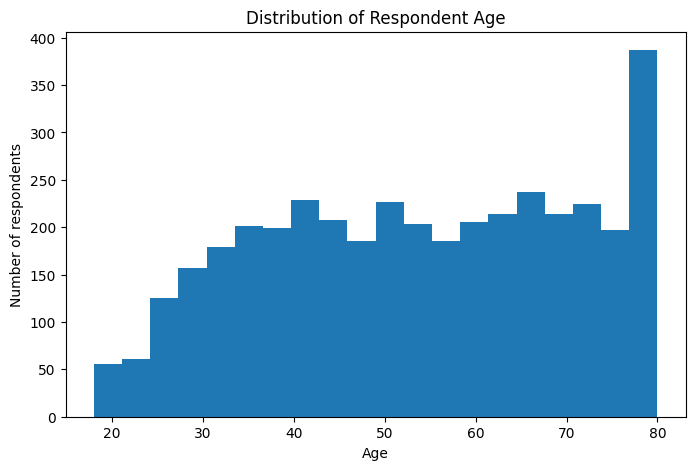

In [16]:
#1. Age histogram
plt.figure(figsize=(8, 5))
plt.hist(df_analysis["age"].dropna(), bins=20)
plt.title("Distribution of Respondent Age")
plt.xlabel("Age")
plt.ylabel("Number of respondents")
plt.show()

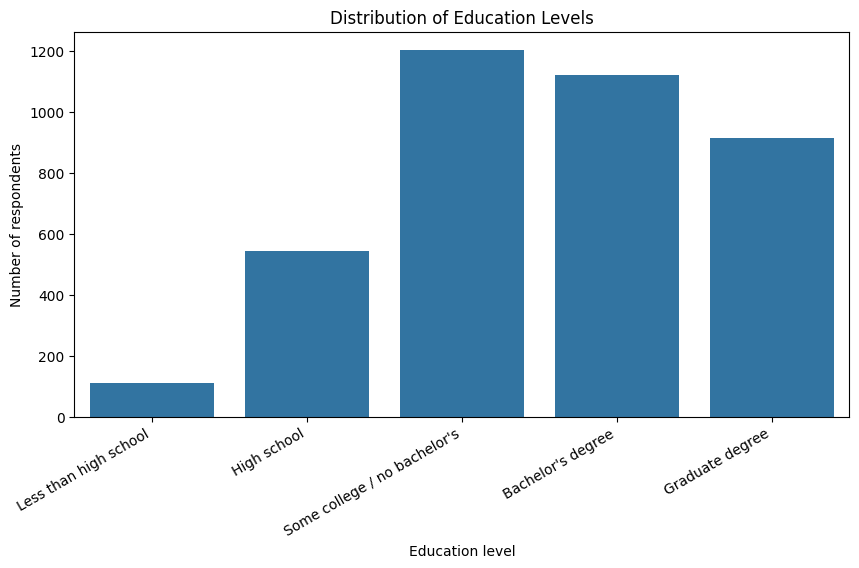

In [17]:
#2. Education bar plot
education_order = list(education_labels.values())

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_analysis,
    x="education_label",
    order=education_order
)
plt.title("Distribution of Education Levels")
plt.xlabel("Education level")
plt.ylabel("Number of respondents")
plt.xticks(rotation=30, ha="right")
plt.show()

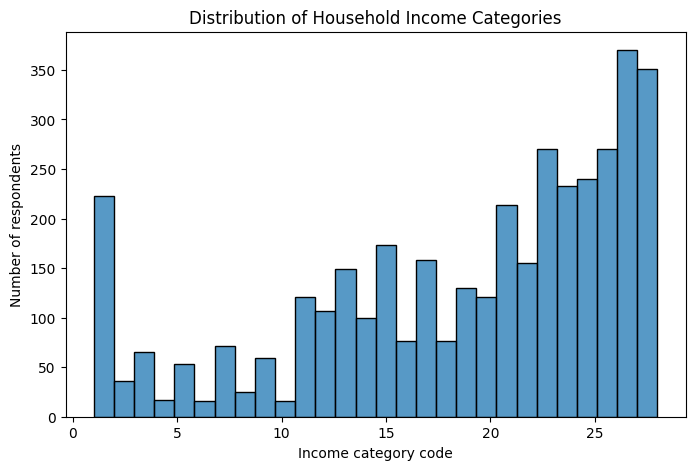

In [18]:
#3. Income histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df_analysis, x="income", bins=28)
plt.title("Distribution of Household Income Categories")
plt.xlabel("Income category code")
plt.ylabel("Number of respondents")
plt.show()

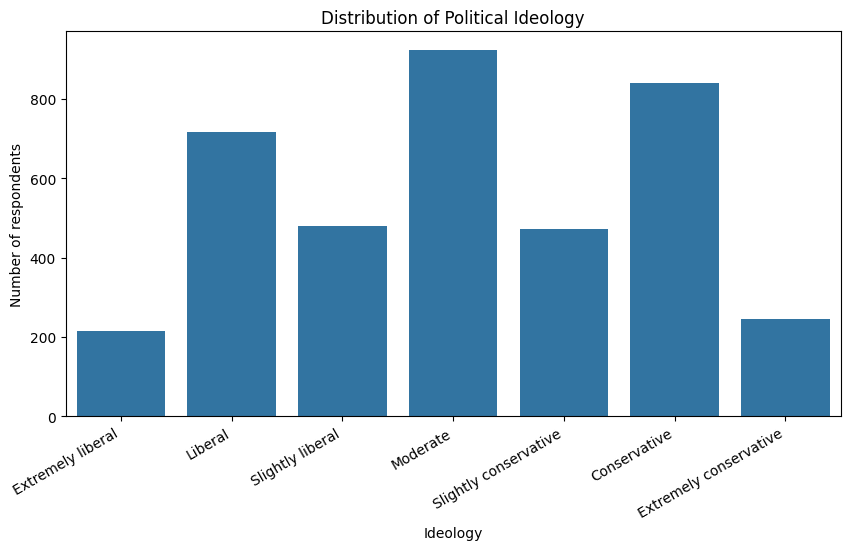

In [19]:
#4. Ideology bar plot
ideology_order = list(ideology_labels.values())

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_analysis,
    x="ideology_label",
    order=ideology_order
)
plt.title("Distribution of Political Ideology")
plt.xlabel("Ideology")
plt.ylabel("Number of respondents")
plt.xticks(rotation=30, ha="right")
plt.show()

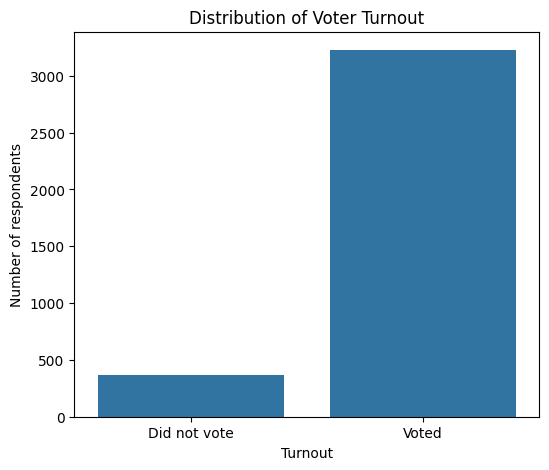

In [20]:
#5. Voter turnout bar plot
plt.figure(figsize=(6, 5))
sns.countplot(
    data=df_analysis,
    x="voter_turnout_label",
    order=["Did not vote", "Voted"]
)
plt.title("Distribution of Voter Turnout")
plt.xlabel("Turnout")
plt.ylabel("Number of respondents")
plt.show()

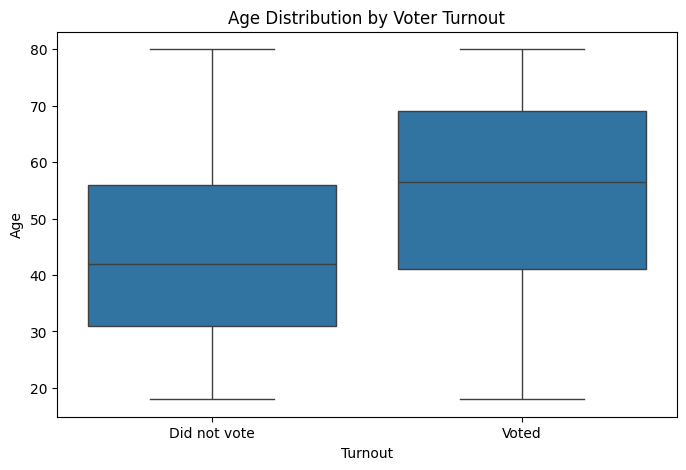

In [21]:
#6. 
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_analysis,
    x="voter_turnout_label",
    y="age",
    order=["Did not vote", "Voted"]
)
plt.title("Age Distribution by Voter Turnout")
plt.xlabel("Turnout")
plt.ylabel("Age")
plt.show()

## 6.1. Additional visualization: respondents by state

This choropleth map shows how many respondents in the cleaned analysis dataset come from each U.S. state. This is not an election result map: it only shows the geographical distribution of respondents in this dataset.

I include this map as an additional visualization because geography is important for U.S. election data, and the map helps show whether the cleaned sample is distributed evenly across states.

In [27]:
import plotly.express as px

state_abbreviations = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY"
}

state_counts = (
    df_analysis["state_name"]
    .value_counts()
    .rename_axis("state_name")
    .reset_index(name="respondent_count")
)

state_counts["state_code"] = state_counts["state_name"].map(state_abbreviations)

state_counts["respondent_share_pct"] = (
    state_counts["respondent_count"] / len(df_analysis) * 100
)

state_counts["rank"] = (
    state_counts["respondent_count"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

state_counts = state_counts.sort_values("respondent_count", ascending=False)

display(state_counts.head(10))

,state_name,respondent_count,state_code,respondent_share_pct,rank
0,California,337,CA,8.652118,1
1,Texas,281,TX,7.214377,2
2,Florida,225,FL,5.776637,3
3,New York,155,NY,3.979461,4
4,Illinois,155,IL,3.979461,4
5,Michigan,142,MI,3.645700,5
6,Pennsylvania,139,PA,3.568678,6
7,Ohio,125,OH,3.209243,7
8,Missouri,122,MO,3.132221,8
9,Georgia,119,GA,3.055199,9


In [24]:
fig = px.choropleth(
    state_counts,
    locations="state_code",
    locationmode="USA-states",
    color="respondent_count",
    scope="usa",
    hover_name="state_name",
    custom_data=[
        "respondent_count",
        "respondent_share_pct",
        "rank"
    ],
    color_continuous_scale="Blues",
    labels={
        "respondent_count": "Respondents"
    },
    title="Number of ANES 2024 Respondents by State"
)

fig.update_traces(
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "Respondents: %{customdata[0]:,}<br>"
        "Share of cleaned dataset: %{customdata[1]:.2f}%<br>"
        "Rank by respondent count: %{customdata[2]}"
        "<extra></extra>"
    )
)

fig.update_layout(
    title={
        "text": "Number of ANES 2024 Respondents by State",
        "x": 0.5,
        "xanchor": "center"
    },
    margin={"r": 0, "t": 60, "l": 0, "b": 0}
)

fig.show()

The map shows that respondents are not distributed equally across states. States with larger populations, such as California, Texas, Florida, and New York, usually have more respondents in the dataset.

Importantly, this map does **not** show election results. It only shows how many respondents in the cleaned dataset come from each state.

## 7. Detailed overview

In this section, I compare voting behavior across demographic and geographic groups. The goal is to move beyond simple one-variable plots and examine relationships between variables.

I focus on:

- major-party presidential vote by race/ethnicity, gender, education, and ideology;
- voter turnout by age group and income group;
- state-level patterns using choropleth maps.

These comparisons are based on the cleaned ANES survey sample, not official election results.

### 7.1. Preparing data for detailed comparisons

For presidential vote comparisons, I first create a dataset with respondents who have a valid presidential vote answer. Then, for most vote-choice plots, I focus on the two major-party candidates: Kamala Harris and Donald Trump.

This makes the comparisons easier to interpret because third-party candidates have much smaller numbers of respondents in this dataset.

In [28]:
df_voters = df_analysis.dropna(subset=["presidential_vote_label"]).copy()

major_candidate_order = ["Kamala Harris", "Donald Trump"]

df_major_party_voters = df_voters[
    df_voters["presidential_vote_label"].isin(major_candidate_order)
].copy()

print("Rows in full analysis dataset:", df_analysis.shape[0])
print("Rows with valid presidential vote:", df_voters.shape[0])
print("Rows with major-party presidential vote:", df_major_party_voters.shape[0])

Rows in full analysis dataset: 3895
Rows with valid presidential vote: 3181
Rows with major-party presidential vote: 3110


In [29]:
def make_percentage_table(data, group_col, outcome_col, group_order=None, outcome_order=None):
    subset = data.dropna(subset=[group_col, outcome_col]).copy()

    counts = pd.crosstab(
        subset[group_col],
        subset[outcome_col]
    )

    percentages = pd.crosstab(
        subset[group_col],
        subset[outcome_col],
        normalize="index"
    ) * 100

    if group_order is not None:
        existing_groups = [group for group in group_order if group in percentages.index]
        counts = counts.reindex(existing_groups)
        percentages = percentages.reindex(existing_groups)

    if outcome_order is not None:
        counts = counts.reindex(columns=outcome_order, fill_value=0)
        percentages = percentages.reindex(columns=outcome_order, fill_value=0)

    return counts, percentages


def plot_percentage_comparison(percentages, title, xlabel, ylabel="Percentage within group"):
    ax = percentages.plot(
        kind="bar",
        figsize=(10, 6)
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="")
    plt.ylim(0, 100)
    plt.show()

### 7.2. Major-party presidential vote by race/ethnicity

This comparison shows whether major-party presidential vote differs across race/ethnicity groups.

Percentages are calculated within each group. This means the chart compares vote distribution inside each group, not the raw number of respondents in each group.

In [30]:
race_order = list(race_labels.values())

vote_by_race_counts, vote_by_race_pct = make_percentage_table(
    data=df_major_party_voters,
    group_col="race_ethnicity_label",
    outcome_col="presidential_vote_label",
    group_order=race_order,
    outcome_order=major_candidate_order
)

display(vote_by_race_counts)
display(vote_by_race_pct.round(2))

presidential_vote_label,Kamala Harris,Donald Trump
race_ethnicity_label,,
"White, non-Hispanic",1312,1152
"Black, non-Hispanic",178,19
Hispanic,172,79
"Asian or Native Hawaiian/other Pacific Islander, non-Hispanic",60,30
"Native American/Alaska Native or other race, non-Hispanic",3,7
"Multiple races, non-Hispanic",54,44


presidential_vote_label,Kamala Harris,Donald Trump
race_ethnicity_label,,
"White, non-Hispanic",53.25,46.75
"Black, non-Hispanic",90.36,9.64
Hispanic,68.53,31.47
"Asian or Native Hawaiian/other Pacific Islander, non-Hispanic",66.67,33.33
"Native American/Alaska Native or other race, non-Hispanic",30.00,70.00
"Multiple races, non-Hispanic",55.10,44.90


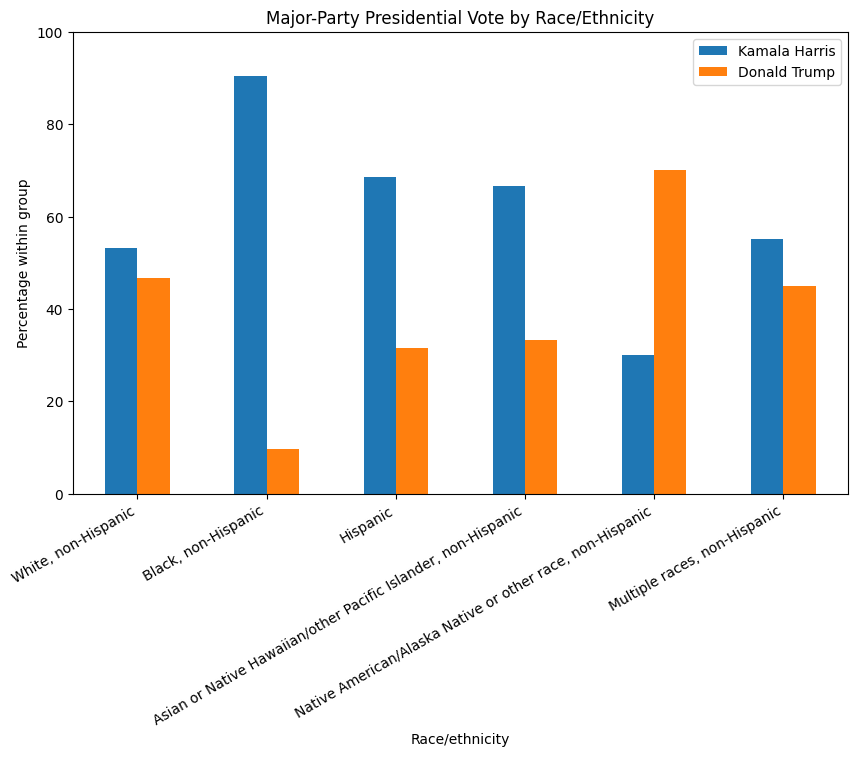

In [31]:
plot_percentage_comparison(
    percentages=vote_by_race_pct,
    title="Major-Party Presidential Vote by Race/Ethnicity",
    xlabel="Race/ethnicity"
)

The chart compares the share of major-party voters in each race/ethnicity group who reported voting for Kamala Harris or Donald Trump.

Groups with smaller respondent counts should be interpreted carefully because a small number of respondents can make percentages less stable.

### 7.3. Major-party presidential vote by gender

This comparison shows whether the distribution of major-party presidential vote differs across gender groups.

In [32]:
gender_order = list(gender_labels.values())

vote_by_gender_counts, vote_by_gender_pct = make_percentage_table(
    data=df_major_party_voters,
    group_col="gender_label",
    outcome_col="presidential_vote_label",
    group_order=gender_order,
    outcome_order=major_candidate_order
)

display(vote_by_gender_counts)
display(vote_by_gender_pct.round(2))

presidential_vote_label,Kamala Harris,Donald Trump
gender_label,,
Man,752,727
Woman,999,600
Non-binary,25,1
Another gender,3,3


presidential_vote_label,Kamala Harris,Donald Trump
gender_label,,
Man,50.85,49.15
Woman,62.48,37.52
Non-binary,96.15,3.85
Another gender,50.00,50.00


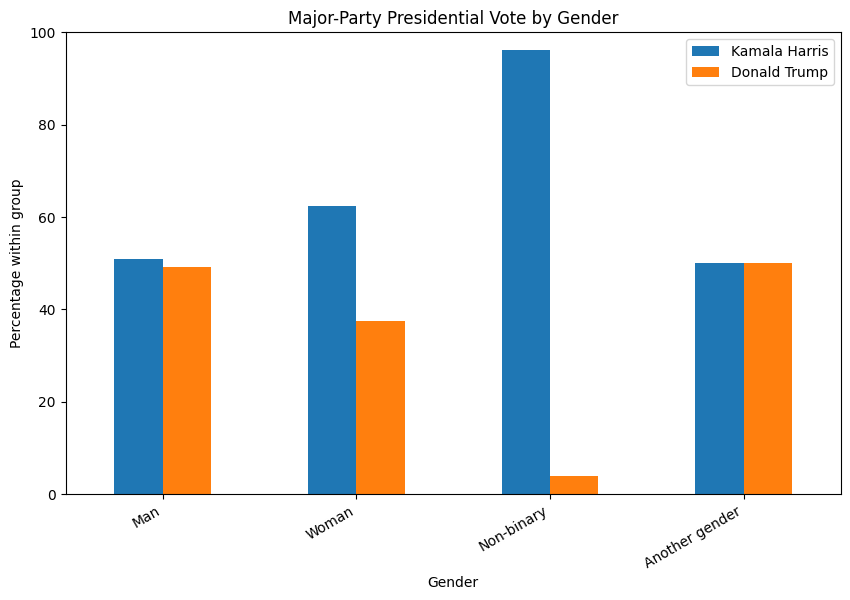

In [33]:
plot_percentage_comparison(
    percentages=vote_by_gender_pct,
    title="Major-Party Presidential Vote by Gender",
    xlabel="Gender"
)

The table and chart compare major-party vote choice across gender groups. Since percentages are calculated within each gender group, the chart shows the share of respondents in each group who voted for each major-party candidate.

Groups with small counts should again be interpreted carefully.

### 7.4. Major-party presidential vote by education group

This comparison shows how major-party presidential vote differs by simplified education group. I use the transformed `education_group` column instead of all five original education categories because it makes the comparison easier to read.

In [34]:
education_group_order = [
    "No college degree",
    "Bachelor's degree",
    "Graduate degree"
]

vote_by_education_counts, vote_by_education_pct = make_percentage_table(
    data=df_major_party_voters,
    group_col="education_group",
    outcome_col="presidential_vote_label",
    group_order=education_group_order,
    outcome_order=major_candidate_order
)

display(vote_by_education_counts)
display(vote_by_education_pct.round(2))

presidential_vote_label,Kamala Harris,Donald Trump
education_group,,
No college degree,616,763
Bachelor's degree,579,365
Graduate degree,584,203


presidential_vote_label,Kamala Harris,Donald Trump
education_group,,
No college degree,44.67,55.33
Bachelor's degree,61.33,38.67
Graduate degree,74.21,25.79


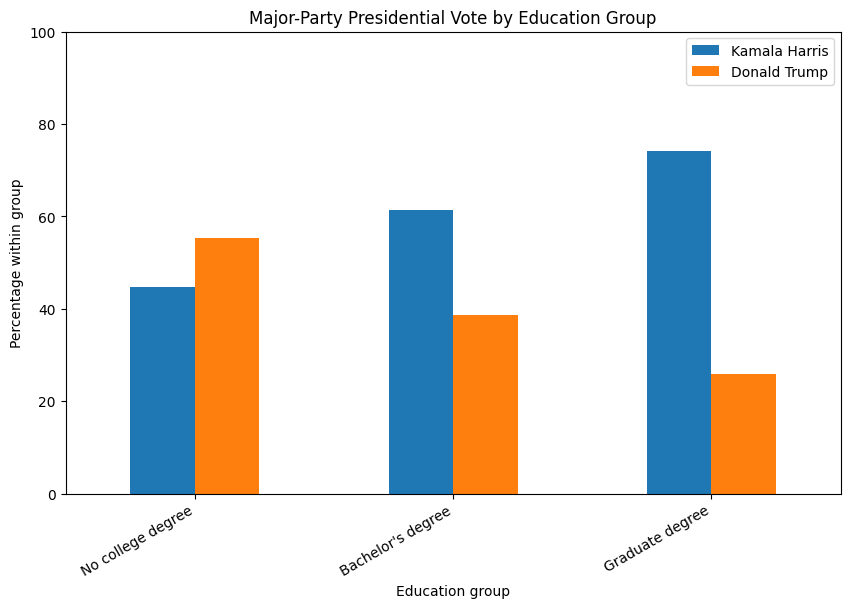

In [35]:
plot_percentage_comparison(
    percentages=vote_by_education_pct,
    title="Major-Party Presidential Vote by Education Group",
    xlabel="Education group"
)

This comparison shows whether major-party presidential vote choice differs across education groups. The simplified education groups make the pattern easier to read than using all five original education categories.

### 7.5. Voter turnout by age group

This comparison shows whether reported voter turnout differs across age groups. Since `voter_turnout` is coded as 0 = did not vote and 1 = voted, the mean of this variable can be interpreted as the share of respondents who voted.

In [36]:
age_group_order = ["18-29", "30-44", "45-64", "65+"]

turnout_by_age_counts, turnout_by_age_pct = make_percentage_table(
    data=df_analysis,
    group_col="age_group",
    outcome_col="voter_turnout_label",
    group_order=age_group_order,
    outcome_order=["Did not vote", "Voted"]
)

display(turnout_by_age_counts)
display(turnout_by_age_pct.round(2))

voter_turnout_label,Did not vote,Voted
age_group,,
18-29,73,229
30-44,131,774
45-64,112,1086
65+,53,1137


voter_turnout_label,Did not vote,Voted
age_group,,
18-29,24.17,75.83
30-44,14.48,85.52
45-64,9.35,90.65
65+,4.45,95.55


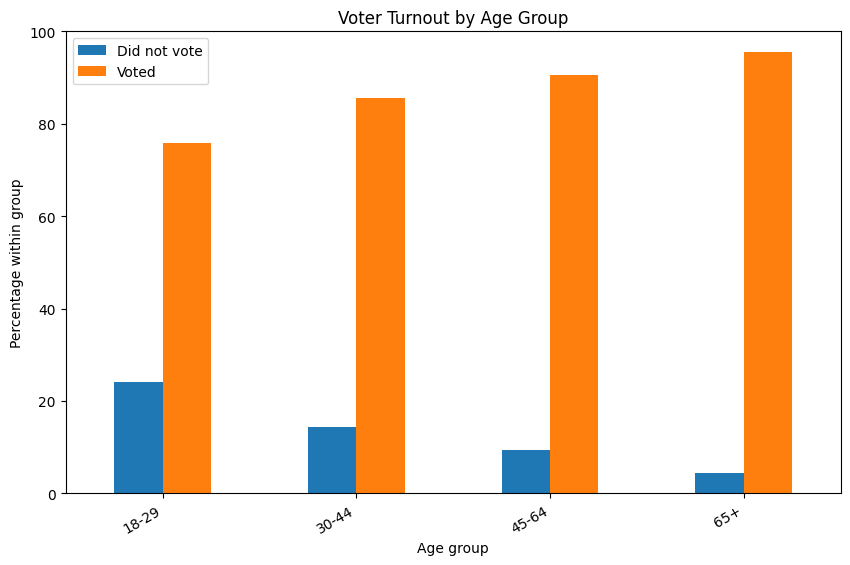

In [37]:
plot_percentage_comparison(
    percentages=turnout_by_age_pct,
    title="Voter Turnout by Age Group",
    xlabel="Age group"
)

age_group
18-29    75.83
30-44    85.52
45-64    90.65
65+      95.55
Name: voter_turnout, dtype: float64

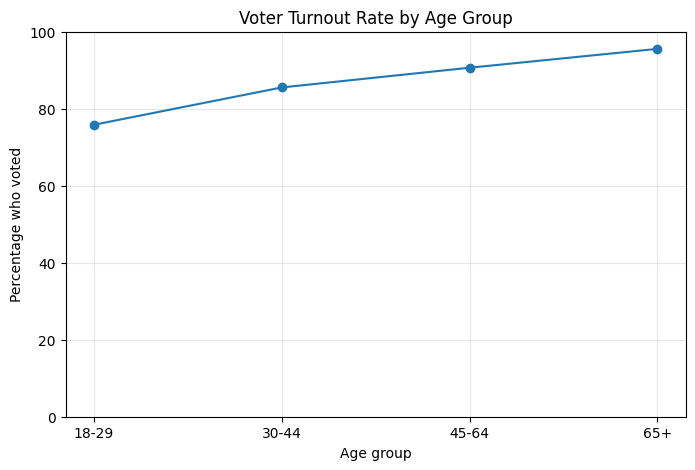

In [38]:
turnout_rate_by_age = (
    df_analysis
    .dropna(subset=["age_group", "voter_turnout"])
    .groupby("age_group", observed=True)["voter_turnout"]
    .mean()
    .reindex(age_group_order)
    * 100
)

display(turnout_rate_by_age.round(2))

plt.figure(figsize=(8, 5))
plt.plot(
    turnout_rate_by_age.index.astype(str),
    turnout_rate_by_age.values,
    marker="o"
)
plt.title("Voter Turnout Rate by Age Group")
plt.xlabel("Age group")
plt.ylabel("Percentage who voted")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.show()

The bar plot shows the full turnout distribution for each age group. The line plot focuses only on the percentage who voted. The line plot is useful here because age groups have a natural order from youngest to oldest.

### 7.6. Voter turnout by income group

This comparison shows whether reported voter turnout differs between lower, middle, and higher income categories.

In [39]:
income_group_order = [
    "Lower income categories",
    "Middle income categories",
    "Higher income categories"
]

turnout_by_income_counts, turnout_by_income_pct = make_percentage_table(
    data=df_analysis,
    group_col="income_group",
    outcome_col="voter_turnout_label",
    group_order=income_group_order,
    outcome_order=["Did not vote", "Voted"]
)

display(turnout_by_income_counts)
display(turnout_by_income_pct.round(2))

voter_turnout_label,Did not vote,Voted
income_group,,
Lower income categories,101,421
Middle income categories,128,1003
Higher income categories,140,1802


voter_turnout_label,Did not vote,Voted
income_group,,
Lower income categories,19.35,80.65
Middle income categories,11.32,88.68
Higher income categories,7.21,92.79


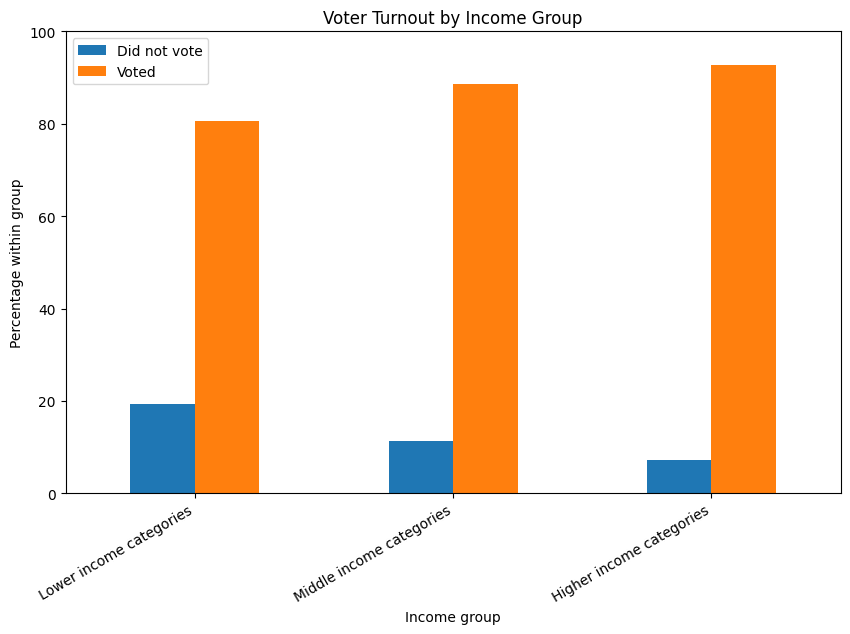

In [40]:
plot_percentage_comparison(
    percentages=turnout_by_income_pct,
    title="Voter Turnout by Income Group",
    xlabel="Income group"
)

income_group
Lower income categories     80.65
Middle income categories    88.68
Higher income categories    92.79
Name: voter_turnout, dtype: float64

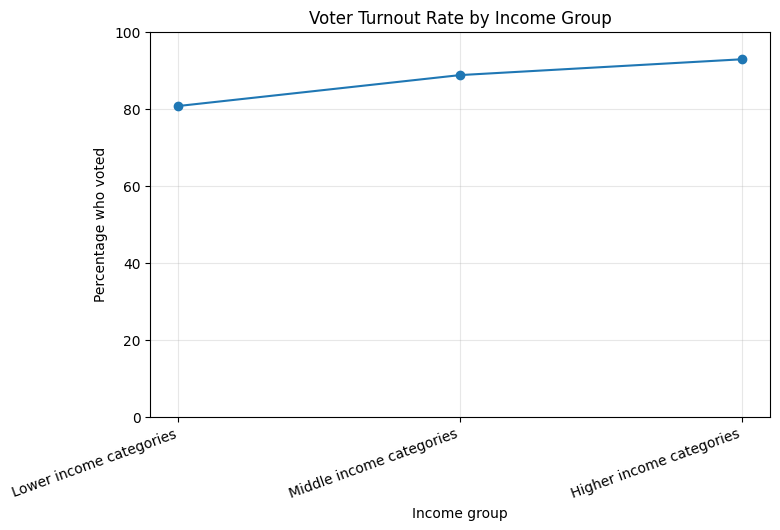

In [41]:
turnout_rate_by_income = (
    df_analysis
    .dropna(subset=["income_group", "voter_turnout"])
    .groupby("income_group", observed=True)["voter_turnout"]
    .mean()
    .reindex(income_group_order)
    * 100
)

display(turnout_rate_by_income.round(2))

plt.figure(figsize=(8, 5))
plt.plot(
    turnout_rate_by_income.index.astype(str),
    turnout_rate_by_income.values,
    marker="o"
)
plt.title("Voter Turnout Rate by Income Group")
plt.xlabel("Income group")
plt.ylabel("Percentage who voted")
plt.ylim(0, 100)
plt.xticks(rotation=20, ha="right")
plt.grid(True, alpha=0.3)
plt.show()

This comparison shows how turnout differs across income groups. The percentages are calculated within each income group, so the chart compares turnout rates rather than raw counts of respondents.

### 7.7. Major-party presidential vote by ideology

This comparison checks whether major-party presidential vote differs across ideology categories. Since ideology is ordered from liberal to conservative, this is one of the most important political comparisons in the project.

In [42]:
ideology_order = list(ideology_labels.values())

vote_by_ideology_counts, vote_by_ideology_pct = make_percentage_table(
    data=df_major_party_voters,
    group_col="ideology_label",
    outcome_col="presidential_vote_label",
    group_order=ideology_order,
    outcome_order=major_candidate_order
)

display(vote_by_ideology_counts)
display(vote_by_ideology_pct.round(2))

presidential_vote_label,Kamala Harris,Donald Trump
ideology_label,,
Extremely liberal,166,9
Liberal,619,14
Slightly liberal,370,25
Moderate,453,193
Slightly conservative,116,231
Conservative,44,660
Extremely conservative,11,199


presidential_vote_label,Kamala Harris,Donald Trump
ideology_label,,
Extremely liberal,94.86,5.14
Liberal,97.79,2.21
Slightly liberal,93.67,6.33
Moderate,70.12,29.88
Slightly conservative,33.43,66.57
Conservative,6.25,93.75
Extremely conservative,5.24,94.76


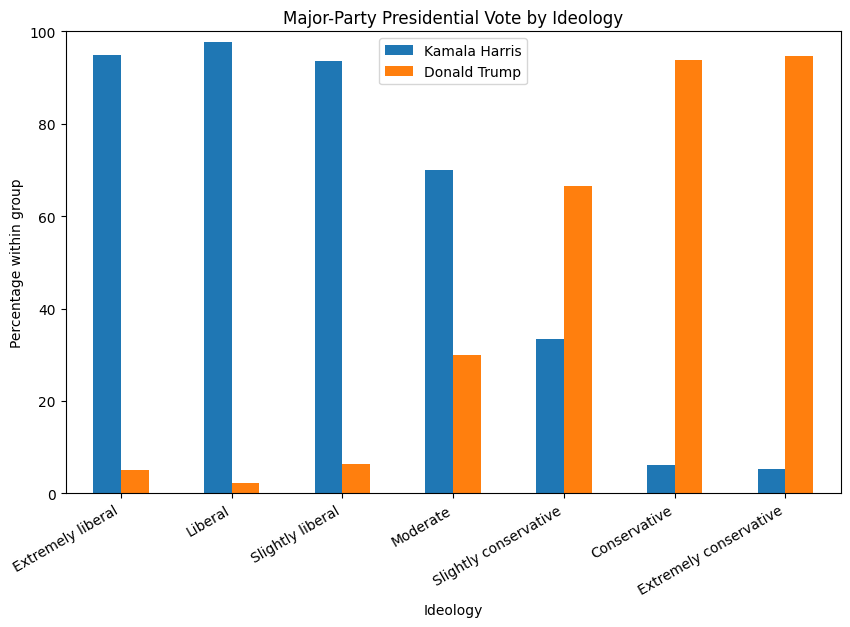

In [43]:
plot_percentage_comparison(
    percentages=vote_by_ideology_pct,
    title="Major-Party Presidential Vote by Ideology",
    xlabel="Ideology"
)

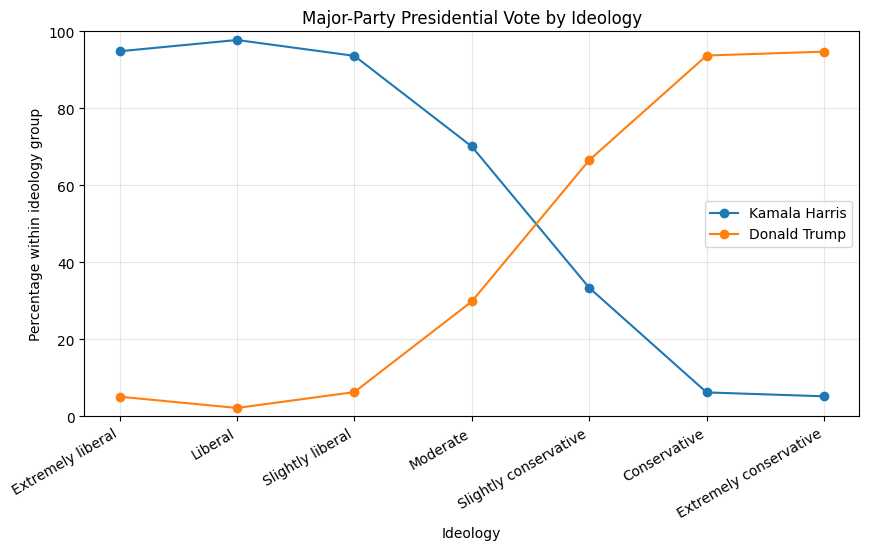

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    vote_by_ideology_pct.index.astype(str),
    vote_by_ideology_pct["Kamala Harris"],
    marker="o",
    label="Kamala Harris"
)

plt.plot(
    vote_by_ideology_pct.index.astype(str),
    vote_by_ideology_pct["Donald Trump"],
    marker="o",
    label="Donald Trump"
)

plt.title("Major-Party Presidential Vote by Ideology")
plt.xlabel("Ideology")
plt.ylabel("Percentage within ideology group")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The ideology comparison shows how presidential vote choice changes across the liberal-conservative scale. The line plot is useful because ideology has a natural order, unlike race or gender categories.

### 7.8. Geographic detailed overview with choropleth maps

I also use choropleth maps to examine state-level patterns in the dataset. These maps do not show official election results. They only summarize the ANES respondents in the cleaned analysis dataset.

State-level survey results should be interpreted carefully, especially for states with small numbers of respondents. For this reason, I include respondent counts in the hover information and create filtered maps using only states with enough respondents.

In [45]:
def add_state_codes(state_summary):
    state_summary = state_summary.copy()
    state_summary["state_code"] = state_summary["state_name"].map(state_abbreviations)
    return state_summary


def plot_state_choropleth(
    state_summary,
    color_column,
    title,
    color_label,
    color_scale="Blues",
    extra_hover_columns=None,
    color_midpoint=None
):
    if extra_hover_columns is None:
        extra_hover_columns = []

    hover_data = {
        "state_code": False,
        color_column: True
    }

    for column in extra_hover_columns:
        hover_data[column] = True

    fig = px.choropleth(
        state_summary,
        locations="state_code",
        locationmode="USA-states",
        color=color_column,
        scope="usa",
        hover_name="state_name",
        hover_data=hover_data,
        color_continuous_scale=color_scale,
        color_continuous_midpoint=color_midpoint,
        labels={color_column: color_label},
        title=title
    )

    fig.update_layout(
        title={
            "text": title,
            "x": 0.5,
            "xanchor": "center"
        },
        margin={"r": 0, "t": 60, "l": 0, "b": 0}
    )

    fig.show()

#### 7.8.1. Respondent count by state

First, I map the number of respondents from each state. This map is useful because it shows where the dataset has more or fewer observations.

In [46]:
state_sample_size = (
    df_analysis
    .groupby("state_name", observed=True)
    .size()
    .reset_index(name="respondent_count")
)

state_sample_size["respondent_share_pct"] = (
    state_sample_size["respondent_count"] / len(df_analysis) * 100
)

state_sample_size = add_state_codes(state_sample_size)

display(
    state_sample_size
    .sort_values("respondent_count", ascending=False)
    .head(10)
)

,state_name,respondent_count,respondent_share_pct,state_code
4,California,337,8.652118,CA
43,Texas,281,7.214377,TX
9,Florida,225,5.776637,FL
32,New York,155,3.979461,NY
13,Illinois,155,3.979461,IL
22,Michigan,142,3.645700,MI
38,Pennsylvania,139,3.568678,PA
35,Ohio,125,3.209243,OH
25,Missouri,122,3.132221,MO
10,Georgia,119,3.055199,GA


In [47]:
plot_state_choropleth(
    state_summary=state_sample_size,
    color_column="respondent_count",
    title="Number of Respondents by State",
    color_label="Respondents",
    color_scale="Blues",
    extra_hover_columns=["respondent_share_pct"]
)

This map shows the geographical distribution of respondents in the cleaned dataset. States with larger populations usually have more respondents, but this is still a survey sample, not a full count of voters.

#### 7.8.2. Voter turnout rate by state

Next, I map the percentage of respondents who reported voting in each state. I only include states with at least 30 respondents, because percentages based on very small groups can be misleading.

In [48]:
minimum_state_respondents = 30

turnout_by_state = (
    df_analysis
    .dropna(subset=["state_name", "voter_turnout"])
    .groupby("state_name", observed=True)
    .agg(
        respondent_count=("respondent_id", "count"),
        turnout_rate_pct=("voter_turnout", lambda x: x.mean() * 100)
    )
    .reset_index()
)

turnout_by_state = turnout_by_state[
    turnout_by_state["respondent_count"] >= minimum_state_respondents
].copy()

turnout_by_state = add_state_codes(turnout_by_state)

display(
    turnout_by_state
    .sort_values("turnout_rate_pct", ascending=False)
    .head(10)
)

,state_name,respondent_count,turnout_rate_pct,state_code
15,Iowa,48,97.916667,IA
36,Oklahoma,36,97.222222,OK
38,Pennsylvania,134,95.522388,PA
23,Minnesota,78,94.871795,MN
5,Colorado,76,94.736842,CO
16,Kansas,50,94.000000,KS
33,North Carolina,98,92.857143,NC
49,Wisconsin,96,92.708333,WI
32,New York,147,92.517007,NY
22,Michigan,133,92.481203,MI


In [49]:
plot_state_choropleth(
    state_summary=turnout_by_state,
    color_column="turnout_rate_pct",
    title="Reported Voter Turnout Rate by State",
    color_label="Turnout rate (%)",
    color_scale="Greens",
    extra_hover_columns=["respondent_count"]
)

This map uses the same state variable in a different way: instead of showing how many respondents came from each state, it shows the share of respondents in each state who reported voting. The respondent count is included because state-level percentages are less reliable when the state sample is small.

#### 7.8.3. Major-party vote balance by state

This map compares the share of major-party voters who reported voting for Kamala Harris and Donald Trump in each state. The value shown is:

**Harris percentage minus Trump percentage.**

Positive values mean a higher Harris share among respondents in that state. Negative values mean a higher Trump share among respondents in that state.

In [52]:
major_party_state_vote = (
    df_major_party_voters
    .dropna(subset=["state_name", "presidential_vote_label"])
    .groupby(["state_name", "presidential_vote_label"], observed=True)
    .size()
    .unstack(fill_value=0)
)

for candidate in major_candidate_order:
    if candidate not in major_party_state_vote.columns:
        major_party_state_vote[candidate] = 0

major_party_state_vote["major_party_respondents"] = (
    major_party_state_vote["Kamala Harris"] +
    major_party_state_vote["Donald Trump"]
)

major_party_state_vote["harris_share_pct"] = (
    major_party_state_vote["Kamala Harris"] /
    major_party_state_vote["major_party_respondents"] * 100
)

major_party_state_vote["trump_share_pct"] = (
    major_party_state_vote["Donald Trump"] /
    major_party_state_vote["major_party_respondents"] * 100
)

major_party_state_vote["harris_minus_trump_pct"] = (
    major_party_state_vote["harris_share_pct"] -
    major_party_state_vote["trump_share_pct"]
)

major_party_state_vote = (
    major_party_state_vote
    .reset_index()
)

major_party_state_vote = major_party_state_vote[
    major_party_state_vote["major_party_respondents"] >= 20
].copy()

major_party_state_vote = add_state_codes(major_party_state_vote)

display(
    major_party_state_vote
    .sort_values("harris_minus_trump_pct", ascending=False)
    .head(10)
)

presidential_vote_label,state_name,Donald Trump,Kamala Harris,major_party_respondents,harris_share_pct,trump_share_pct,harris_minus_trump_pct,state_code
4,California,73,185,258,71.705426,28.294574,43.410853,CA
32,New York,38,96,134,71.641791,28.358209,43.283582,NY
47,Washington,26,64,90,71.111111,28.888889,42.222222,WA
20,Maryland,20,48,68,70.588235,29.411765,41.176471,MD
5,Colorado,22,50,72,69.444444,30.555556,38.888889,CO
37,Oregon,20,44,64,68.750000,31.250000,37.500000,OR
31,New Mexico,10,20,30,66.666667,33.333333,33.333333,NM
28,Nevada,8,15,23,65.217391,34.782609,30.434783,NV
22,Michigan,42,77,119,64.705882,35.294118,29.411765,MI
21,Massachusetts,26,47,73,64.383562,35.616438,28.767123,MA


In [53]:
plot_state_choropleth(
    state_summary=major_party_state_vote,
    color_column="harris_minus_trump_pct",
    title="Major-Party Vote Balance by State: Harris Share Minus Trump Share",
    color_label="Harris minus Trump (percentage points)",
    color_scale="RdBu",
    extra_hover_columns=[
        "major_party_respondents",
        "harris_share_pct",
        "trump_share_pct"
    ],
    color_midpoint=0
)

This map is more analytical than the respondent-count map. It compares the balance between the two major-party candidates among respondents in each state.

However, it should not be interpreted as an official state election map. The ANES dataset is a survey sample, and some states have relatively small numbers of respondents.

#### 7.8.4. Average ideology by state

Finally, I use the choropleth map to show the average ideology code by state. The ideology scale goes from 1 = extremely liberal to 7 = extremely conservative. Therefore, higher values indicate a more conservative average ideology among respondents in that state.

In [54]:
ideology_by_state = (
    df_analysis
    .dropna(subset=["state_name", "ideology"])
    .groupby("state_name", observed=True)
    .agg(
        respondent_count=("respondent_id", "count"),
        average_ideology=("ideology", "mean")
    )
    .reset_index()
)

ideology_by_state = ideology_by_state[
    ideology_by_state["respondent_count"] >= minimum_state_respondents
].copy()

ideology_by_state = add_state_codes(ideology_by_state)

display(
    ideology_by_state
    .sort_values("average_ideology", ascending=False)
    .head(10)
)

,state_name,respondent_count,average_ideology,state_code
40,South Carolina,79,4.911392,SC
0,Alabama,70,4.757143,AL
3,Arkansas,45,4.733333,AR
25,Missouri,122,4.663934,MO
18,Louisiana,33,4.606061,LA
42,Tennessee,109,4.504587,TN
43,Texas,281,4.451957,TX
35,Ohio,125,4.376000,OH
16,Kansas,55,4.290909,KS
10,Georgia,119,4.268908,GA


In [55]:
plot_state_choropleth(
    state_summary=ideology_by_state,
    color_column="average_ideology",
    title="Average Ideology by State",
    color_label="Average ideology code",
    color_scale="Oranges",
    extra_hover_columns=["respondent_count"]
)

This map uses the same geographic information in a third way: instead of mapping counts or vote choice, it maps the average ideology score by state. Since ideology is a coded survey scale, the values should be interpreted as average codes, not exact ideology categories.

### 7.9. Summary of detailed overview

In this section, I compared voting behavior across several demographic and geographic groups.

First, I compared major-party presidential vote by race/ethnicity, gender, education, and ideology. Then I compared voter turnout by age group and income group. Finally, I used choropleth maps to examine state-level respondent counts, turnout rates, major-party vote balance, and average ideology.

These comparisons go beyond simple one-variable plots because they show how voting behavior and political variables differ across subsets of respondents. The results should be interpreted as patterns within the ANES survey sample, not as official election results or exact population estimates.

## 8. Hypothesis checking

In this section, I test two hypotheses about the cleaned ANES dataset.
The hypotheses are based on relationships found in the detailed overview.
The goal is not to prove causal relationships, but to check whether the
patterns in the data support or do not support each hypothesis.


### Hypothesis 1
Respondents in older age groups and higher income groups are more likely to
report voting.

This hypothesis uses two conditions at the same time: age group and income
group. If the hypothesis is correct, the highest turnout rates should appear
among older respondents in higher income categories.

In [56]:
hypothesis1_data = df_analysis.dropna(
    subset=["age_group", "income_group", "voter_turnout"]
).copy()

age_group_order = ["18-29", "30-44", "45-64", "65+"]

income_group_order = [
    "Lower income categories",
    "Middle income categories",
    "Higher income categories"
]

turnout_age_income = (
    hypothesis1_data
    .groupby(["age_group", "income_group"], observed=True)["voter_turnout"]
    .mean()
    .mul(100)
    .unstack()
    .reindex(index=age_group_order, columns=income_group_order)
)

turnout_age_income_counts = (
    hypothesis1_data
    .groupby(["age_group", "income_group"], observed=True)["voter_turnout"]
    .count()
    .unstack()
    .reindex(index=age_group_order, columns=income_group_order)
)

display(turnout_age_income.round(2))
display(turnout_age_income_counts)

income_group,Lower income categories,Middle income categories,Higher income categories
age_group,,,
18-29,65.45,67.54,87.22
30-44,65.59,81.55,89.93
45-64,83.02,88.18,93.39
65+,89.30,96.79,97.06


income_group,Lower income categories,Middle income categories,Higher income categories
age_group,,,
18-29,55,114,133
30-44,93,206,606
45-64,159,313,726
65+,215,498,477


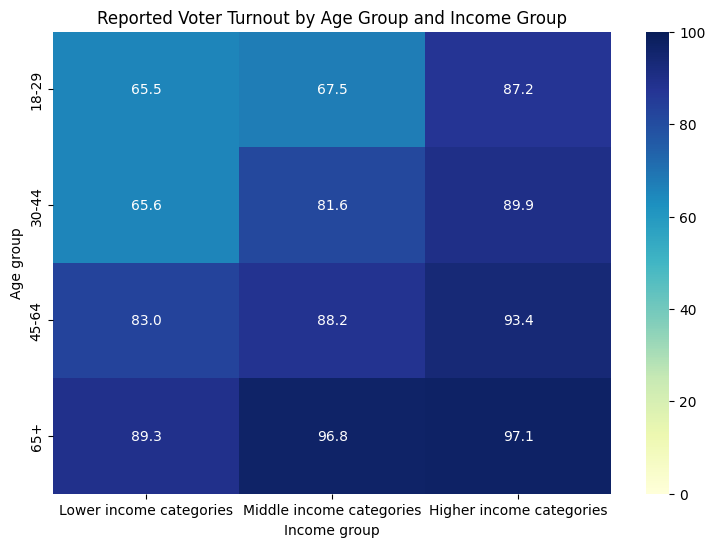

In [57]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    turnout_age_income,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100
)

plt.title("Reported Voter Turnout by Age Group and Income Group")
plt.xlabel("Income group")
plt.ylabel("Age group")
plt.show()

The heatmap shows reported turnout rates for combinations of age group and
income group. This is more informative than looking only at age or only at
income, because it shows how the two variables work together.

If the highest values are concentrated among older and higher-income
respondents, then the hypothesis is supported. If the pattern is mixed or the
differences are small, then the hypothesis is only partially supported.

**Result for Hypothesis 1:** The hypothesis is supported.
The heatmap shows that reported turnout generally increases with both age and
income. Among respondents aged 18-29, turnout ranges from about 65.45% in the
lower income group to 87.22% in the higher income group. Among respondents aged
65+, turnout is much higher in all income groups, reaching about 97.06% in the
higher income group.

This means that both age and income appear to be related to turnout in the
cleaned ANES sample. The highest turnout rates are concentrated among older
and higher-income respondents, which supports the hypothesis.

### Hypothesis 2
The relationship between education and presidential vote choice is different
across ideology groups.

This hypothesis uses three variables: education group, ideology, and
presidential vote choice. If the hypothesis is correct, the Harris/Trump vote
balance should not be the same for all education groups within the same
ideology categories.

In [58]:
hypothesis2_data = df_major_party_voters.dropna(
    subset=["education_group", "ideology_label", "presidential_vote_label"]
).copy()

ideology_order = list(ideology_labels.values())

education_group_order = [
    "No college degree",
    "Bachelor's degree",
    "Graduate degree"
]

harris_share_by_education_ideology = (
    hypothesis2_data
    .assign(voted_harris=lambda x: (x["presidential_vote_label"] == "Kamala Harris").astype(int))
    .groupby(["ideology_label", "education_group"], observed=True)["voted_harris"]
    .mean()
    .mul(100)
    .unstack()
    .reindex(index=ideology_order, columns=education_group_order)
)

harris_share_counts = (
    hypothesis2_data
    .groupby(["ideology_label", "education_group"], observed=True)["presidential_vote_label"]
    .count()
    .unstack()
    .reindex(index=ideology_order, columns=education_group_order)
)

display(harris_share_by_education_ideology.round(2))
display(harris_share_counts)

education_group,No college degree,Bachelor's degree,Graduate degree
ideology_label,,,
Extremely liberal,86.27,97.10,100.00
Liberal,95.29,98.49,99.18
Slightly liberal,87.29,95.65,97.12
Moderate,63.04,72.59,84.25
Slightly conservative,31.36,29.25,44.44
Conservative,5.60,5.29,9.84
Extremely conservative,6.67,0.00,6.90


education_group,No college degree,Bachelor's degree,Graduate degree
ideology_label,,,
Extremely liberal,51,69,55
Liberal,191,199,243
Slightly liberal,118,138,139
Moderate,322,197,127
Slightly conservative,169,106,72
Conservative,393,189,122
Extremely conservative,135,46,29


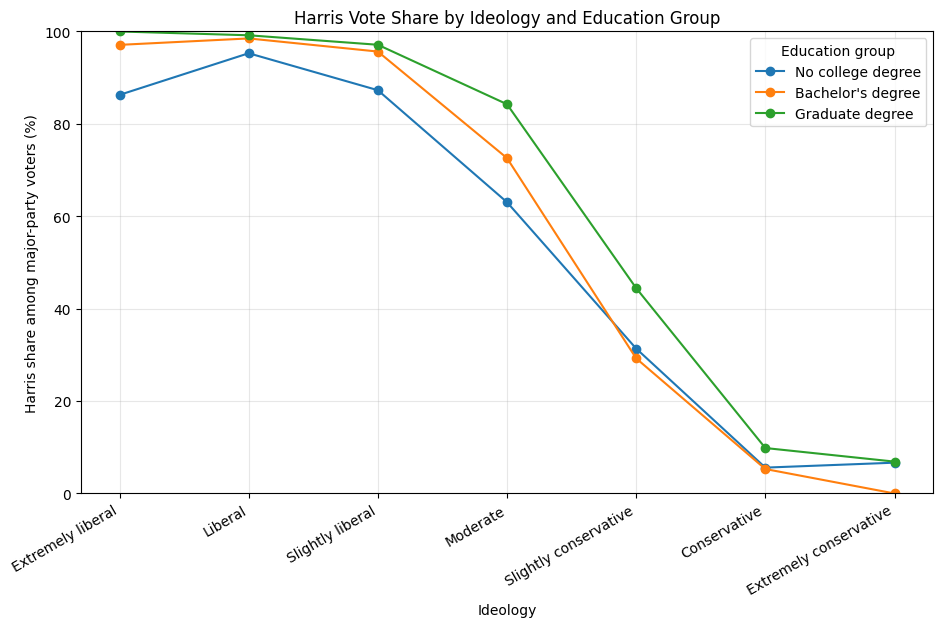

In [59]:
plt.figure(figsize=(11, 6))

for education_group in education_group_order:
    if education_group in harris_share_by_education_ideology.columns:
        plt.plot(
            harris_share_by_education_ideology.index.astype(str),
            harris_share_by_education_ideology[education_group],
            marker="o",
            label=education_group
        )

plt.title("Harris Vote Share by Ideology and Education Group")
plt.xlabel("Ideology")
plt.ylabel("Harris share among major-party voters (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.3)
plt.legend(title="Education group")
plt.show()

This plot shows Harris's share among major-party voters for each combination
of ideology and education group. Since ideology has a natural order, a line
plot is useful here.

If the lines for different education groups are separated within the same
ideology categories, then education appears to be related to vote choice even
after considering ideology. If the lines are very close, then ideology explains
most of the difference and education adds less.

Some categories may have small numbers of respondents, so the count table
should be checked before making strong conclusions.

**Result for Hypothesis 2:** The hypothesis is partially supported.

The plot shows that ideology is strongly related to presidential vote choice:
Harris's vote share is very high among liberal respondents and much lower
among conservative respondents.

Education also matters, but its effect is smaller than ideology. For example,
among moderate respondents, Harris's share rises from about 63.04% among
respondents without a college degree to about 84.25% among respondents with a
graduate degree. This suggests that education is related to vote choice even
within the same ideology category.

However, ideology remains the stronger factor overall. Therefore, the
hypothesis is partially supported: education differences are visible within
some ideology categories, but ideology explains most of the variation in
presidential vote choice.

### Summary of hypothesis checking
The first hypothesis examined whether voter turnout differs by both age group
and income group. The second hypothesis examined whether presidential vote
choice differs by both ideology and education group.

Both hypotheses use more than one condition, which makes them more informative
than simple one-variable comparisons. The results should be interpreted as
exploratory patterns in the cleaned ANES sample, not as causal explanations or
official election estimates.

## 9. Discussion

This project analyzed voting behavior and demographic patterns in the cleaned
ANES 2024 respondent dataset. The analysis focused on variables such as age,
state, race/ethnicity, gender, education, income, ideology, voter turnout, and
presidential vote choice.

The data cleaning stage was important because the original survey data used
special numerical codes for missing or invalid responses. Negative values were
replaced with missing values, and the ideology code 99 was removed because it
does not represent a position on the 1-7 ideology scale. After cleaning, I
created readable labels and several new transformed columns, such as age group,
income group, education group, and major-party vote.

The descriptive statistics showed that the cleaned dataset contains respondents
with a median age of 54. The median education category is "Bachelor's degree",
the median income category is "$80,000-89,999", and the median ideology category
is "Moderate". Voter turnout is high in the cleaned sample, with the mean of
the voter_turnout variable showing that most respondents reported voting.

The basic visualizations showed the distributions of the main variables, while
the detailed overview compared voting behavior across demographic groups. The
comparisons showed clear differences in vote choice by race/ethnicity, gender,
education, and ideology. The strongest political pattern appeared in the
ideology comparison: liberal respondents were much more likely to report voting
for Kamala Harris, while conservative respondents were much more likely to
report voting for Donald Trump.

The choropleth maps added a geographic perspective. They showed the number of
respondents by state, state-level turnout rates, state-level major-party vote
balance, and average ideology by state. These maps are useful for exploring
geographic patterns in the survey sample, but they should not be interpreted as
official state election results.

## 10. Limitations

The main limitation of this project is that the ANES dataset is a survey sample,
not the official election result. Therefore, the results describe patterns among
respondents in the cleaned dataset, not exact outcomes for the whole U.S.
electorate.

Another limitation is that this analysis is unweighted. Survey weights can make
the sample more representative of the population, but this project focuses on
Python data cleaning, visualization, and exploratory analysis rather than formal
survey statistics. Because the analysis is unweighted, candidate shares in the
cleaned dataset may differ from the official 2024 election result.

State-level maps should also be interpreted carefully. Some states have fewer
respondents than others, so state-level percentages can be unstable when the
sample size is small. For this reason, the maps are best understood as
exploratory visualizations of the ANES sample, not as precise state estimates.

Finally, presidential vote and turnout are self-reported survey variables.
Some respondents did not provide valid answers, and those missing values affect
which rows can be used in different parts of the analysis.

## 11. Conclusion

The project shows that the ANES 2024 dataset is suitable for exploring
relationships between demographic variables and voting behavior. The analysis
found meaningful patterns in voter turnout and presidential vote choice.

The first hypothesis was supported: older and higher-income respondents were
generally more likely to report voting. The second hypothesis was partially
supported: education differences were visible within ideology groups, but
ideology itself was the strongest predictor of major-party presidential vote
choice in the cleaned sample.

Overall, the project demonstrates how Python can be used to clean survey data,
create readable variables, calculate descriptive statistics, build visualizations,
compare demographic groups, test hypotheses, and discuss limitations of the
results.